<a href="https://colab.research.google.com/github/AEIBIANCOFCE/AnalisisEstadisticoI/blob/main/2%20Estad%C3%ADstica%20Descriptiva/AEI_Introducci%C3%B3n_al_an%C3%A1lisis_de_datos_con_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Análisis Estadístico I**

### Cátedra: Bianco

#### **Introducción al análisis de datos**

***Material elaborado por la profesora Natalia Salaberry***

Contexto:

Suponga que trabaja como asesor financiero y requiere tomar una decisión acerca de que activo recomendar para invertir perteneciente al sector tecnológico. Particularmente el interés de decisión recae sobre Microsoft y Google.

Para ello será necesario recolectar y analizar información sobre el comportamiento de la cotización de dichos activos.



###**Librerías**

In [ ]:
import pandas as pd
import requests
import numpy as np
import sympy
import statistics as ss
import math
from IPython.display import display, Math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy.stats import t, chi2, norm, f
import yfinance as yf
from datetime import date
from datetime import datetime, timedelta

###**Obtención de datos**

In [ ]:
data=yf.download(['MSFT', 'GOOGL'], start='2024-09-01', end='2026-09-01')['Close']

data

[*********************100%***********************]  2 of 2 completed


Ticker,GOOGL,MSFT
Date,,
2024-09-03,156.055634,403.072662
2024-09-04,155.153137,402.541046
2024-09-05,155.936615,402.038971
2024-09-06,149.669006,395.453033
2024-09-09,147.673035,399.410522
...,...,...
2026-08-25,346.737122,491.709991
2026-08-26,341.780304,496.369995
2026-08-27,340.431183,505.059998


###**Análisis inicial descriptivo**

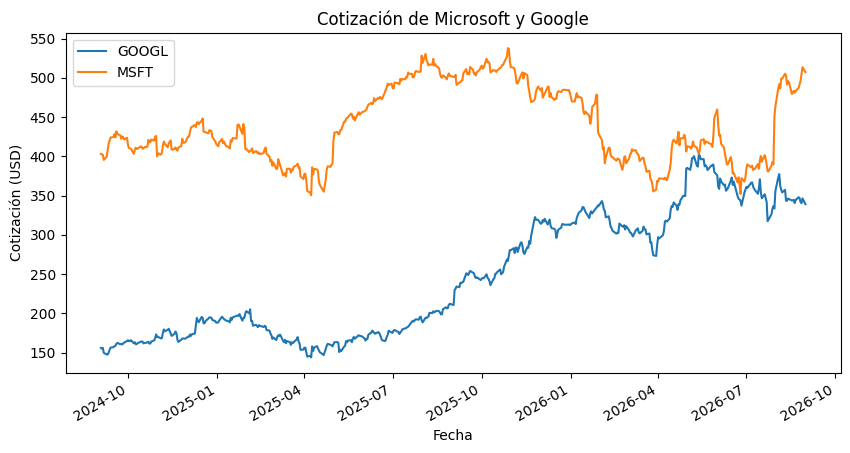

In [ ]:
#observar el comportamiento de la serie de cotización
data['GOOGL'].plot(x=data.index, y=data['GOOGL'], figsize=(10, 5))
data['MSFT'].plot(x=data.index, y=data['MSFT'], figsize=(10, 5))
plt.xlabel("Fecha")
plt.ylabel("Cotización (USD)")
plt.title("Cotización de Microsoft y Google")
plt.legend(['GOOGL', 'MSFT'])
plt.show()

Obtener medidas para analizar

In [ ]:
!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.2 MB/s eta 0:00:00
^C


In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
# ejecutamos el reporte
ProfileReport(data, title="Profiling Report")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 136.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#cáculo de medidas

for col in data:
  print(f'------------------------------')
  print(f'Medidas Estadísticas de ', col)
  print(f'------------------------------')
  print(f'Media', round(np.mean(data[col]),4))
  print(f'Mediana', round(np.median(data[col]),4))
  print(f'Modo', round(ss.mode(data[col]),4))
  print(f'Percentiles')
  print(f'P05:', round(np.percentile(data[col],[10])[0],4), f'P25:', round(np.percentile(data[col],[25])[0],4),
        f'P50:', round(np.percentile(data[col],[50])[0],4), 'P75:', round(np.percentile(data[col],[75])[0],4),
        'P90:', round(np.percentile(data[col],[90])[0],4))
  print(f'RIC', round(np.percentile(data[col],[75])[0],4)-round(np.percentile(data[col],[25])[0],4))
  print(f'Rango', round(data[col].max()- data[col].min(),4))
  print(f'Varianza', round(ss.variance(data[col]),4))
  print(f'Desvío', round(ss.stdev(data[col]),4))
  print(f'Coeficiente de variación', round(ss.stdev(data[col])/np.mean(data[col]),4))
  print(f'Coeficiente de asimetría', round(data[col].skew(),4))
  print(f'Coeficiente de Curtosis', round(data[col].kurtosis(),4))



------------------------------
Medidas Estadísticas de  GOOGL
------------------------------
Media 246.478
Mediana 221.0121
Modo 164.7034
Percentiles
P05: 161.5943 P25: 171.6795 P50: 221.0121 P75: 318.8807 P90: 355.9262
RIC 147.2012
Rango 258.0999
Varianza 6187.504
Desvío 78.6607
Coeficiente de variación 0.3191
Coeficiente de asimetría 0.3306
Coeficiente de Curtosis -1.4452
------------------------------
Medidas Estadísticas de  MSFT
------------------------------
Media 439.2914
Mediana 424.905
Modo 480.4221
Percentiles
P05: 382.9083 P25: 402.4807 P50: 424.905 P75: 484.7124 P90: 506.8082
RIC 82.23169999999999
Rango 187.2003
Varianza 2264.6584
Desvío 47.5884
Coeficiente de variación 0.1083
Coeficiente de asimetría 0.2561
Coeficiente de Curtosis -1.2276


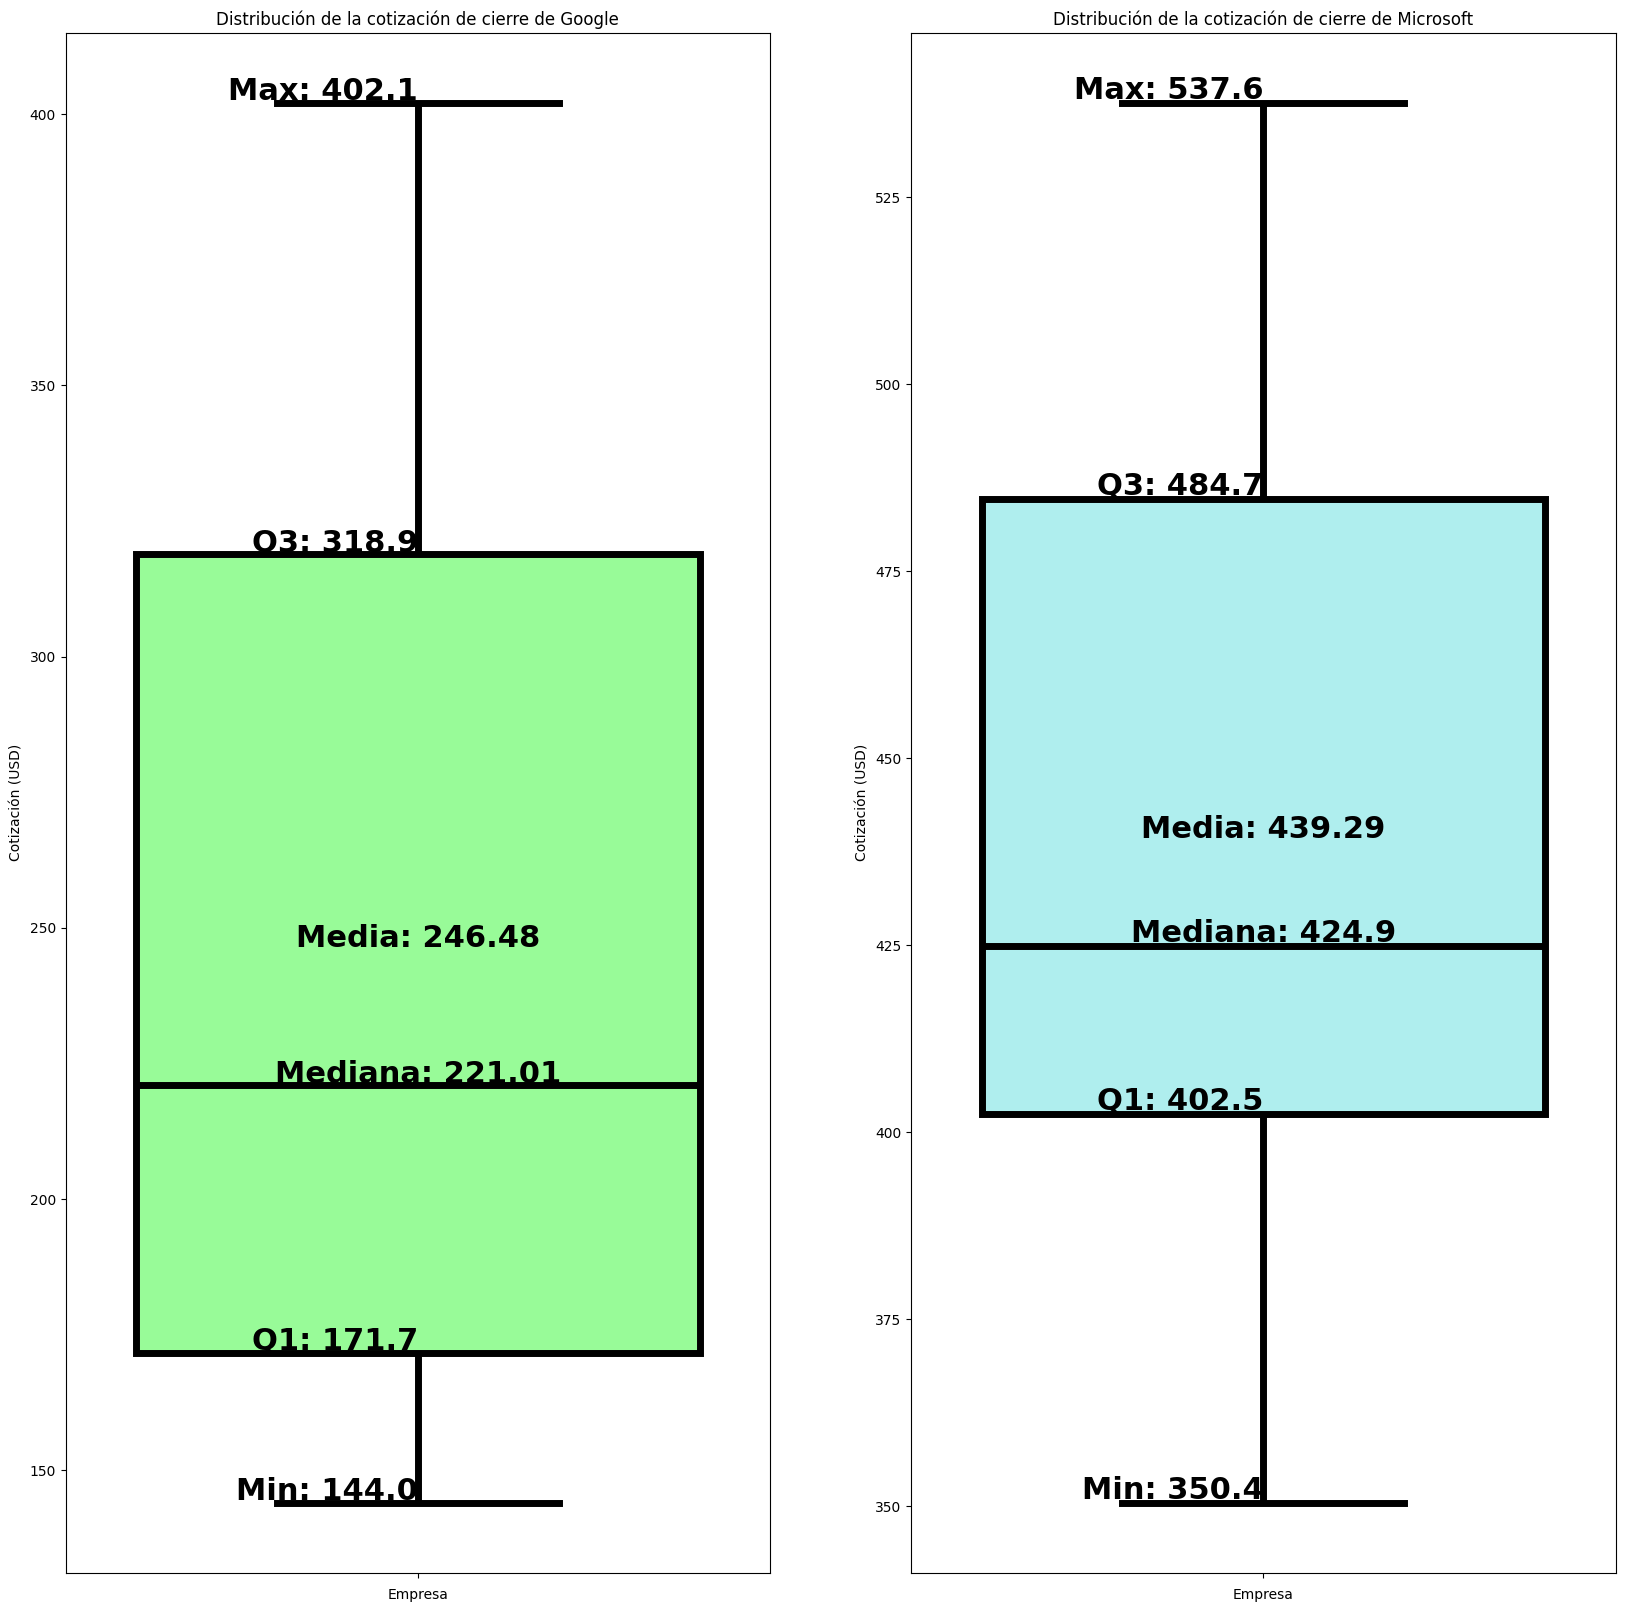

In [ ]:
#Boxplots con medidas
import statistics as stat

m1_G = round([data['GOOGL'].median()][0],2) #mediana
p25_G = round([np.percentile(data['GOOGL'], 25)][0],1) #P25
p75_G = round([np.percentile(data['GOOGL'], 75)][0],1) #P75
med_G=round(stat.mean(data['GOOGL']),2) #media
max_G=round(data['GOOGL'].max(),1) #máximo
min_G=round(data['GOOGL'].min(),1) #mínimo

m1_M = round([data['MSFT'].median()][0],2) #mediana
p25_M = round([np.percentile(data['MSFT'], 25)][0],1) #P25
p75_M = round([np.percentile(data['MSFT'], 75)][0],1) #P75
med_M=round(stat.mean(data['MSFT']),2) #media
max_M=round(data['MSFT'].max(),1) #máximo
min_M=round(data['MSFT'].min(),1) #mínimo

plt.figure(figsize=(20, 20))
plt.subplot(1,2,1)
g=sns.boxplot(data=data['GOOGL'], color='palegreen', orient='v', saturation=2, linewidth=5, fliersize=20, linecolor='black')
plt.title('Distribución de la cotización de cierre de Google')
plt.xlabel('Empresa')
plt.ylabel('Cotización (USD)')
plt.subplot(1,2,2)
m=sns.boxplot(data=data['MSFT'], color='paleturquoise', orient='v', saturation=2, linewidth=5, fliersize=20, linecolor='black')
plt.title('Distribución de la cotización de cierre de Microsoft')
plt.xlabel('Empresa')
plt.ylabel('Cotización (USD)')

for xtick in g.get_xticks():
   g.text(xtick,max_G+0.5,'Max:'+' '+str(max_G),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   g.text(xtick,min_G+0.5,'Min:'+' '+str(min_G),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   g.text(xtick,m1_G+0.5,'Mediana:'+' '+str(m1_G),horizontalalignment='center',fontsize=22,color='black',weight='semibold')
   g.text(xtick,med_G,'Media:'+' '+str(med_G),horizontalalignment='center',fontsize=22,color='black',weight='semibold')
   g.text(xtick,p25_G+0.5,'Q1:'+' '+str(p25_G),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   g.text(xtick,p75_G+0.5,'Q3:'+' '+str(p75_G),horizontalalignment='right',fontsize=22,color='black',weight='semibold')

for xtick in m.get_xticks():
   m.text(xtick,max_M+0.5,'Max:'+' '+str(max_M),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   m.text(xtick,min_M+0.5,'Min:'+' '+str(min_M),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   m.text(xtick,m1_M+0.5,'Mediana:'+' '+str(m1_M),horizontalalignment='center',fontsize=22,color='black',weight='semibold')
   m.text(xtick,med_M,'Media:'+' '+str(med_M),horizontalalignment='center',fontsize=22,color='black',weight='semibold')
   m.text(xtick,p25_M+0.5,'Q1:'+' '+str(p25_M),horizontalalignment='right',fontsize=22,color='black',weight='semibold')
   m.text(xtick,p75_M+0.5,'Q3:'+' '+str(p75_M),horizontalalignment='right',fontsize=22,color='black',weight='semibold')


plt.show()

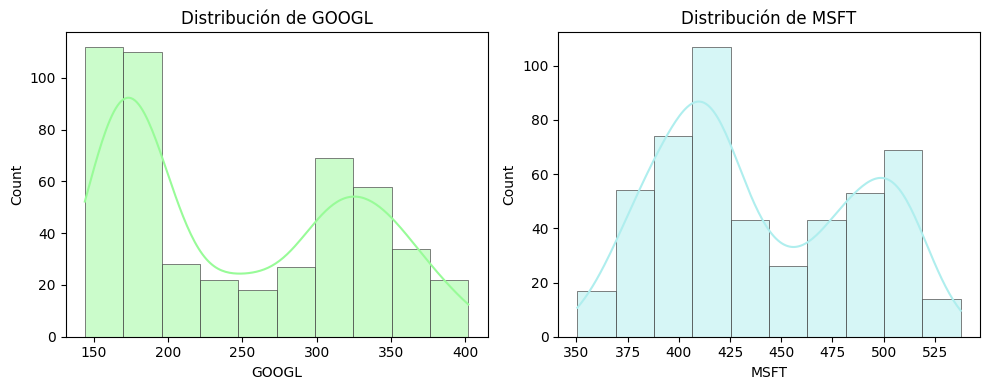

In [ ]:
#Histogramas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data["GOOGL"],ax=axes[0],color="palegreen",edgecolor=".3",linewidth=0.5,kde=True)
axes[0].set_title("Distribución de GOOGL")

sns.histplot(data["MSFT"],ax=axes[1],color="paleturquoise",edgecolor=".3",linewidth=0.5,kde=True)
axes[1].set_title("Distribución de MSFT")

plt.tight_layout()
plt.show()

#Variables específicas de análisis

Las dos principales variables de análisis son el retorno histórico de un activo y la volatilidad.

El retorno de un activo, en términos porcentuales, se obtiene como:

$R_t = {P_t - P_{t-1} \over P_{t-1}} $

El retorno esperado de un activo, se obtiene como:

Retorno Esperado = $ \sum_{t=1}^n R_t \over n $

La volatilidad histórica (riesgo), se calcula como el desvío de los retornos:

$ \sigma = \sqrt {\sum_{t=1}^n (R_t - \bar R)^2 \over n-1}$

A partir de tener este conocimiento, construir las medidas y analizarlas con el objetivo de tomar una decisión en que activo invertir.

###**Cálculo de Retorno y volatilidad**

In [ ]:
data['MSFT_ret']=data['MSFT'].pct_change()
data['GOOGL_ret']=data['GOOGL'].pct_change()
data

Ticker,GOOGL,MSFT,MSFT_ret,GOOGL_ret
Date,,,,
2024-09-03,156.055634,403.072662,NaN,NaN
2024-09-04,155.153137,402.541046,-0.001319,-0.005783
2024-09-05,155.936615,402.038971,-0.001247,0.005050
2024-09-06,149.669006,395.453033,-0.016381,-0.040193
2024-09-09,147.673035,399.410522,0.010007,-0.013336
...,...,...,...,...
2026-08-25,346.737122,491.709991,0.009029,-0.003160
2026-08-26,341.780304,496.369995,0.009477,-0.014296
2026-08-27,340.431183,505.059998,0.017507,-0.003947


In [ ]:
#Google

print(f'------')
print(f'GOOGLE')
print(f'------')
# Retorno esperado (promedio muestral de los retornos diarios)
RE_G = data['GOOGL_ret'].mean()
# Volatilidad (desviación muestral de los retornos diarios)
Desv_RG = data['GOOGL_ret'].std()
# Mostrar resultados
print(f"Retorno esperado de GOOG: {RE_G * 100:.2f}%")
print(f"Volatilidad de GOOG: {Desv_RG * 100:.2f}%")

#Microsoft
print(f'------')
print(f'MICROSOFT')
print(f'------')
# Retorno esperado (promedio muestral de los retornos diarios)
RE_M = data['MSFT_ret'].mean()
# Volatilidad (desviación muestral de los retornos diarios)
Desv_RM = data['MSFT_ret'].std()
# Mostrar resultados
print(f"Retorno esperado de MSFT: {RE_M * 100:.2f}%")
print(f"Volatilidad de MSFT: {Desv_RM * 100:.2f}%")

------
GOOGLE
------
Retorno esperado de GOOG: 0.18%
Volatilidad de GOOG: 2.01%
------
MICROSOFT
------
Retorno esperado de MSFT: 0.06%
Volatilidad de MSFT: 1.82%


###**Análisis**

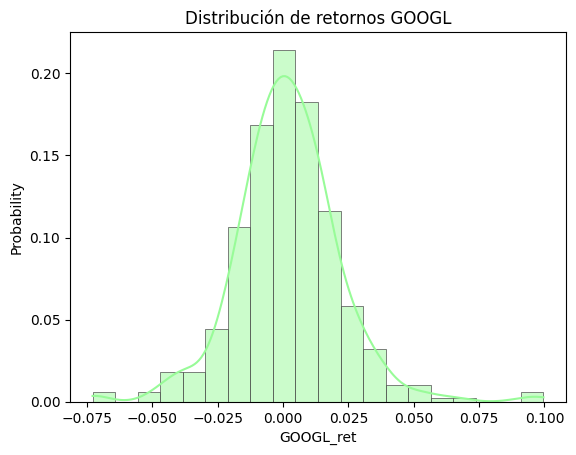

In [ ]:
#observamos distribución de los retornos
sns.histplot(x=data['GOOGL_ret'], color="palegreen",edgecolor=".3",linewidth=.5,stat='probability', bins=20, kde=True) #histograma
plt.title('Distribución de retornos GOOGL')

plt.show()

¿Es leptocúrtica la distribución de los retornos de GOOGL?

¿Es simétrica la distirbución de los retornos GOOGL?

In [ ]:
data_g=pd.DataFrame(data['GOOGL_ret'])
data_g.columns=['GOOGL_ret']
if round(data_g.kurtosis()[0],4)>3:
  print(f'Coeficiente de Curtosis', round(data_g.kurtosis()[0],4), f'=> Distribución Leptocúrtica')
else:
  print(f'Coeficiente de Curtosis', round(data_g.kurtosis()[0],4), f'=> Distribución Platicúrtica')
if round(data_g.skew()[0],4)>0:
  print(f'Coeficiente de asimetría', round(data_g.skew()[0],4), f'=> Distribución Asimetrica positiva')
elif round(data_g.skew()[0],4)<0:
  print(f'Coeficiente de asimetría', round(data_g.skew()[0],4), f'=> Distribución Asimetrica negativa')
else:
  print(f'Coeficiente de asimetría', round(data_g.skew()[0],4), f'=> Distribución Simétrica')

Coeficiente de Curtosis 3.4867 => Distribución Leptocúrtica
Coeficiente de asimetría 0.4188 => Distribución Asimetrica positiva


En las colas de la distribución de los Retornos de GOOGL, ¿hay presencia de valores atípicos? Si la respuesta es si, ¿són moderados o severos?

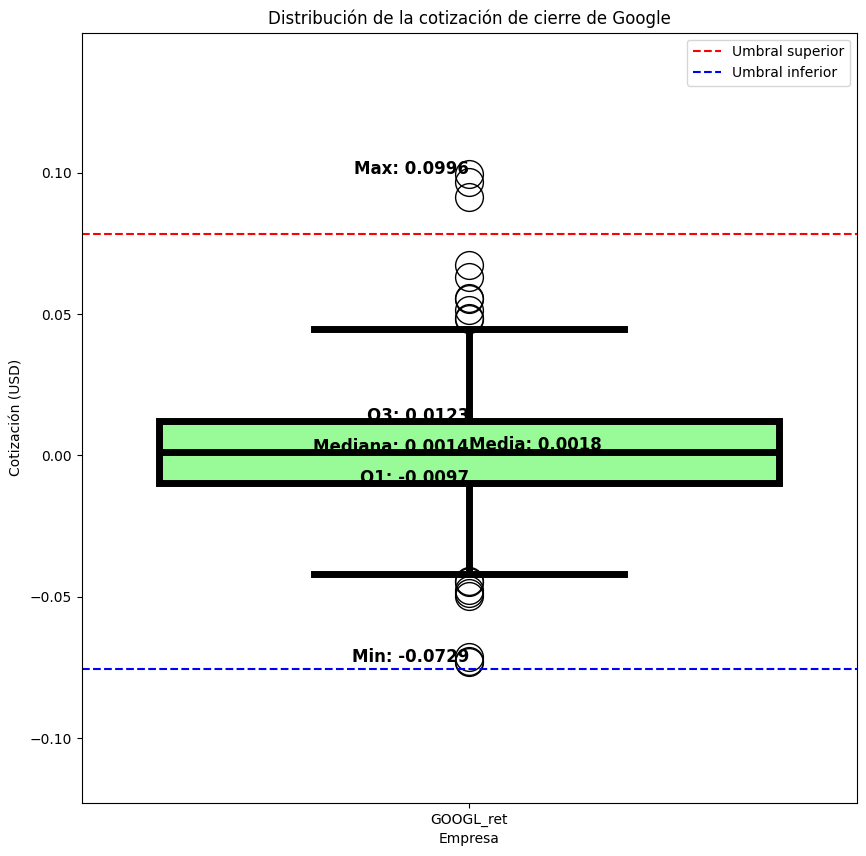

In [ ]:
import statistics as stat

data_g=pd.DataFrame(data['GOOGL_ret'].dropna())
data_g.columns=['GOOGL_ret']

m1_G = round(data_g.median()[0],4)
p25_G = round(np.percentile(data_g['GOOGL_ret'], 25),4)
p75_G = round(np.percentile(data_g['GOOGL_ret'], 75),4)
med_G=round(data_g['GOOGL_ret'].mean(),4)
max_G=round(data_g['GOOGL_ret'].max(),4)
min_G=round(data_g['GOOGL_ret'].min(),4)

plt.figure(figsize=(10, 10))
g=sns.boxplot(data=data_g, color='palegreen', orient='v', saturation=2, linewidth=5, fliersize=20, linecolor='black')
plt.ylim(min_G-0.05, max_G+0.05)
plt.title('Distribución de la cotización de cierre de Google')
plt.xlabel('Empresa')
plt.ylabel('Cotización (USD)')

for xtick in g.get_xticks():
   g.text(xtick,max_G,'Max:'+' '+str(max_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,min_G,'Min:'+' '+str(min_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,m1_G,'Mediana:'+' '+str(m1_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,med_G,'Media:'+' '+str(med_G),horizontalalignment='left',fontsize=12,color='black',weight='semibold')
   g.text(xtick,p25_G,'Q1:'+' '+str(p25_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,p75_G,'Q3:'+' '+str(p75_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')

plt.axhline(y=p75_G + 3 * (p75_G - p25_G), color='red', linestyle='--', label='Umbral superior')
plt.axhline(y=p25_G - 3 * (p75_G - p25_G), color='blue', linestyle='--', label='Umbral inferior')
plt.legend()
plt.show()

¿Entre que valores se encuentra el 50% central de la distribución de los restornos de GOOGL? ¿Diría que el rango determinado anterioremente es amplío o no?

¿tiene variabilidad (riesgo) alta o baja la distirbución de GOOGL?



In [ ]:
print(f'Rango del 50% central RIC:',p75_G-p25_G)
print(f'Rango de la distirbución', max_G-min_G)
print(f'Desvío de la distirbución', round(data_g['GOOGL_ret'].std(),4))

Rango del 50% central RIC: 0.022
Rango de la distirbución 0.1725
Desvío de la distirbución 0.0201


Ahora podemos calcular la probabilidad de ganar o perder respecto de un umbral de ganancia requerido

In [ ]:
threshold = 0.01 #umbral definido: obtener ganancia del 1%

# Calcular la probabilidad de obtener un retorno mayor al umbral
from scipy.stats import norm
probability_greater = 1 - norm.cdf(threshold, loc=RE_G, scale=Desv_RG)
# Calcular la probabilidad de obtener un retorno menor al umbral
probability_less = norm.cdf(threshold, loc=RE_G, scale=Desv_RG)

print(f"Probabilidad de obtener un retorno de GOOGL mayor a {threshold * 100}%: {round(probability_greater*100,2)}%")
print(f"Probabilidad de obtener un retorno de GOOGL menor a {threshold * 100}%: {round(probability_less*100,2)}%")

Probabilidad de obtener un retorno de GOOGL mayor a 1.0%: 34.06%
Probabilidad de obtener un retorno de GOOGL menor a 1.0%: 65.94%


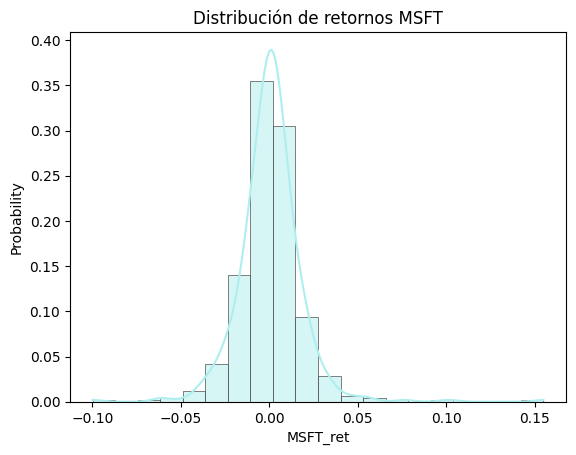

In [ ]:
sns.histplot(x=data['MSFT_ret'], color="paleturquoise",edgecolor=".3",linewidth=.5,stat='probability', bins=20, kde=True) #histograma
plt.title('Distribución de retornos MSFT')

plt.show()

¿Es leptocúrtica la distribución de los retornos de MSFT?

¿Es simétrica la distirbución de los retornos MSFT?

In [ ]:
data_m=pd.DataFrame(data['MSFT_ret'])
data_m.columns=['MSFT_ret']
if round(data_g.kurtosis()[0],4)>3:
  print(f'Coeficiente de Curtosis', round(data_m.kurtosis()[0],4), f'=> Distribución Leptocúrtica')
else:
  print(f'Coeficiente de Curtosis', round(data_m.kurtosis()[0],4), f'=> Distribución Platicúrtica')
if round(data_g.skew()[0],4)>0:
  print(f'Coeficiente de asimetría', round(data_m.skew()[0],4), f'=> Distribución Asimetrica positiva')
elif round(data_g.skew()[0],4)<0:
  print(f'Coeficiente de asimetría', round(data_m.skew()[0],4), f'=> Distribución Asimetrica negativa')
else:
  print(f'Coeficiente de asimetría', round(data_m.skew()[0],4), f'=> Distribución Simétrica')

Coeficiente de Curtosis 14.3604 => Distribución Leptocúrtica
Coeficiente de asimetría 1.2484 => Distribución Asimetrica positiva


En las colas de la distribución de los Retornos de MSFT, ¿hay presencia de valores atípicos? Si la respuesta es si, ¿són moderados o severos?

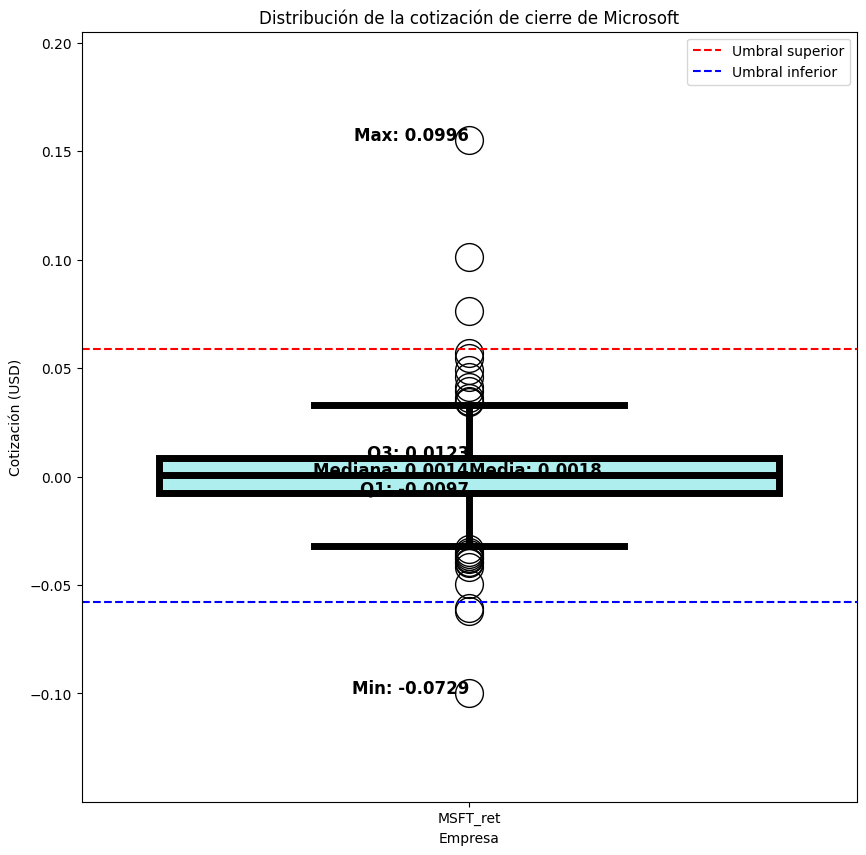

In [ ]:
import statistics as stat

data_m=pd.DataFrame(data['MSFT_ret'].dropna())
data_m.columns=['MSFT_ret']

m1_M = round(data_m.median()[0],4)
p25_M = round(np.percentile(data_m['MSFT_ret'], 25),4)
p75_M = round(np.percentile(data_m['MSFT_ret'], 75),4)
med_M=round(data_m['MSFT_ret'].mean(),4)
max_M=round(data_m['MSFT_ret'].max(),4)
min_M=round(data_m['MSFT_ret'].min(),4)

plt.figure(figsize=(10, 10))
g=sns.boxplot(data=data_m, color='paleturquoise', orient='v', saturation=2, linewidth=5, fliersize=20, linecolor='black')
plt.ylim(min_M-0.05, max_M+0.05)
plt.title('Distribución de la cotización de cierre de Microsoft')
plt.xlabel('Empresa')
plt.ylabel('Cotización (USD)')

for xtick in g.get_xticks():
   g.text(xtick,max_M,'Max:'+' '+str(max_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,min_M,'Min:'+' '+str(min_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,m1_M,'Mediana:'+' '+str(m1_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,med_M,'Media:'+' '+str(med_G),horizontalalignment='left',fontsize=12,color='black',weight='semibold')
   g.text(xtick,p25_M,'Q1:'+' '+str(p25_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')
   g.text(xtick,p75_M,'Q3:'+' '+str(p75_G),horizontalalignment='right',fontsize=12,color='black',weight='semibold')

plt.axhline(y=p75_M + 3 * (p75_M - p25_M), color='red', linestyle='--', label='Umbral superior')
plt.axhline(y=p25_M - 3 * (p75_M - p25_M), color='blue', linestyle='--', label='Umbral inferior')
plt.legend()
plt.show()

¿Entre que valores se encuentra el 50% central de la distribución de los restornos de MSFT? ¿Diría que el rango determinado anterioremente es amplío o no?

¿tiene variabilidad (riesgo) alta o baja la distirbución de MSFT?



In [ ]:
print(f'Rango del 50% central RIC:',p75_M-p25_M)
print(f'Rango de la distirbución', max_M-min_M)
print(f'Desvío de la distirbución', round(data_m['MSFT_ret'].std(),4))

Rango del 50% central RIC: 0.0166
Rango de la distirbución 0.255
Desvío de la distirbución 0.0182


Ahora podemos calcular la probabilidad de ganar o perder respecto de un umbral de ganancia requerido

In [ ]:

threshold = 0.01 #umbral definido: obtener ganancia del 1%

# Calcular la probabilidad de obtener un retorno mayor al umbral
from scipy.stats import norm
probability_greater = 1 - norm.cdf(threshold, loc=RE_M, scale=Desv_RM)
# Calcular la probabilidad de obtener un retorno menor al umbral
probability_less = norm.cdf(threshold, loc=RE_M, scale=Desv_RM)


print(f"Probabilidad de obtener un retorno de MSFT mayor a {threshold * 100}%: {round(probability_greater*100,2)}%")
print(f"Probabilidad de obtener un retorno de MSFT menor a {threshold * 100}%: {round(probability_less*100,2)}%")

Probabilidad de obtener un retorno de MSFT mayor a 1.0%: 30.3%
Probabilidad de obtener un retorno de MSFT menor a 1.0%: 69.7%
